<a href="https://colab.research.google.com/github/Aurorcys/FirstMLRSI/blob/main/RSIMACDML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def downloadstock(ticker, period='2y'):
  data = yf.Downlaod(ticker, period=period)
  return data

In [ ]:


import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def calculate_rsi(close, period=14):
    delta = close.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# Your data preparation - FIX: Extract just the Close prices
data = yf.download('AAPL', period='2y')
close_prices = data['Close']  # This is a Series, not DataFrame
volume = data['Volume']       # This is a Series

# Create a clean DataFrame with our features
clean_data = pd.DataFrame()
clean_data['Close'] = close_prices
clean_data['Volume'] = volume

# Calculate indicators on the clean DataFrame
clean_data['RSI'] = calculate_rsi(clean_data['Close'])
clean_data['MACD'] = clean_data['Close'].ewm(span=12).mean() - clean_data['Close'].ewm(span=26).mean()
clean_data['Volume_Ratio'] = clean_data['Volume'] / clean_data['Volume'].rolling(20).mean()

# Now this will work - RSI divergence
clean_data['RSI_oversold'] = (clean_data['RSI'] < 30).astype(int)
clean_data['RSI_overbought'] = (clean_data['RSI'] > 70).astype(int)

clean_data['Tomorrow_Up'] = (clean_data['Close'].shift(-1) > clean_data['Close']).astype(int)
clean_data = clean_data.dropna()

# Train model
features = ['RSI', 'MACD', 'Volume_Ratio', 'RSI_overbought', 'RSI_oversold']
X = clean_data[features]
y = clean_data['Tomorrow_Up']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

print("=== FEATURE IMPORTANCE ===")
for feature, imp in zip(features, model.feature_importances_):
    print(f"{feature}: {imp:.1%}")

accuracy = model.score(X_test, y_test)
print(f"\nAccuracy: {accuracy:.1%}")

/tmp/ipython-input-3243662886.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', period='2y')
[*********************100%***********************]  1 of 1 completed


=== FEATURE IMPORTANCE ===
RSI: 32.2%
MACD: 33.6%
Volume_Ratio: 32.5%
RSI_overbought: 1.0%
RSI_oversold: 0.7%

Accuracy: 49.5%


Choose your stock to train on: LRN


/tmp/ipython-input-1475966780.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(choice, period='2y')
[*********************100%***********************]  1 of 1 completed


Calculating indicators
Training...

Model Accuracy: 50.0%

Feature Importance
RSI: 33.1%
PgChange: 33.5%
Volume Ratio: 33.3%

=== TRADING RESULTS ===
Starting: $10,000.00
Final: $8,592.47
Profit: $-1,407.53 (-14.1%)
Number of trades: 35
Buy & Hold: $4,705.93 ($-5,294.07)


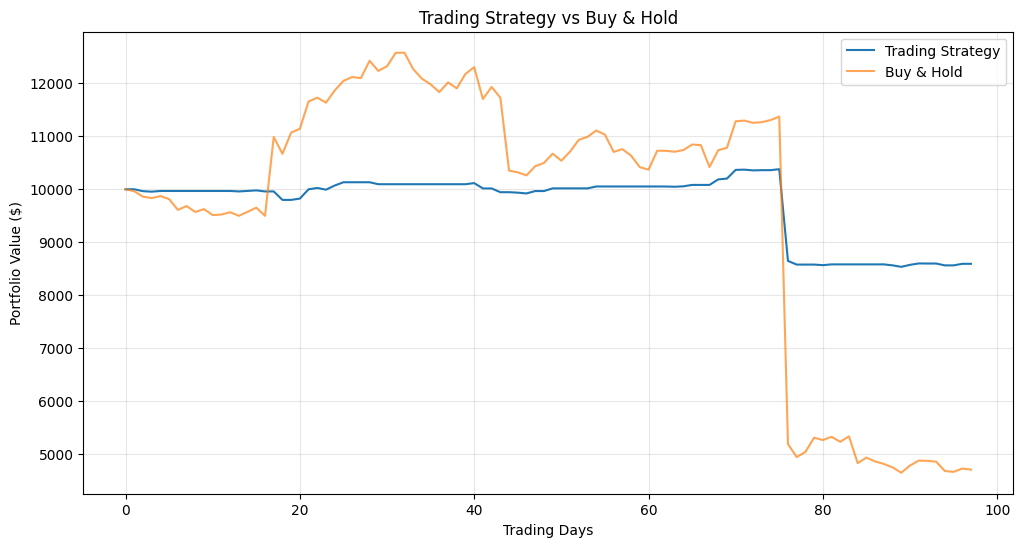


Dummy Classifier (always predict majority): 50.0%


In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


def calculate_rsi(closes, period=14):
  pricechanges = closes.diff()
  gains = pricechanges.where(pricechanges > 0, 0)
  loss = -pricechanges.where(pricechanges < 0, 0)

  avggain = gains.rolling(window=period).mean()
  avgloss = loss.rolling(window=period).mean()


  rs = avggain / avgloss
  rsi = 100 - (100 / (1 + rs))
  return rsi


choice = input('Choose your stock to train on: ')
print(f'Downloading stock data of {choice}')
data = yf.download(choice, period='2y')

df = pd.DataFrame()
df['Close'] = data['Close']
df['Volume'] = data['Volume']

print('Calculating indicators')
df['RSI'] = calculate_rsi(df['Close'])
df['PgChange'] = df['Close'].pct_change()
df['Volume Ratio'] = df['Volume'] / df['Volume'].rolling(5).mean()

#create trading indicators

df['Tmr Up'] = (df['Close'].shift(-1) > df['Close']).astype(int)

df = df.dropna()

features = ['RSI', 'PgChange', 'Volume Ratio']
X = df[features]
y = df['Tmr Up']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle=False)

print('Training...')
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f'\nModel Accuracy: {accuracy:.1%}')

print('\nFeature Importance')
feature_names = features
importances = model.feature_importances_

for name, importance in zip(feature_names, importances):
  print(f'{name}: {importance:.1%}')



def simulation(model, X_test, prices, initial=10000):
  cash = initial
  shares = 0
  trades = []
  portfolio = []

  for i in range(len(X_test)):
    currentf = X_test.iloc[i:i+1]
    currentclose = float(prices.iloc[i])

    prediction = model.predict(currentf)[0]
    probability = model.predict_proba(currentf)[0][1]

    if probability > 0.55 and shares == 0:
      risk = 0.1 + (probability - 0.55) * (0.4) / 0.35
      sharestobuy = (cash*risk  ) / currentclose
      cash -= sharestobuy*currentclose
      shares += sharestobuy
      trades.append(f'BOUGHT {sharestobuy} SHARES AT ${currentclose}, USING ${sharestobuy*currentclose}')
    elif probability < 0.45 and shares > 0:
      cash += shares*currentclose
      trades.append(f'SOLD {shares} SHARES AT ${currentclose} GAINING ${shares*currentclose}')
      shares = 0
    portfolio.append(cash + shares*currentclose)

  return portfolio, trades


test_indices = X_test.index
test_prices = df.loc[test_indices, 'Close']
portfolio, trades = simulation(model, X_test, test_prices)

initial_cash = 10000
profit = portfolio[-1] - initial_cash
profit_percentage = (profit / initial_cash) * 100

print(f"\n=== TRADING RESULTS ===")
print(f"Starting: ${initial_cash:,.2f}")
print(f"Final: ${portfolio[-1]:,.2f}")
print(f"Profit: ${profit:,.2f} ({profit_percentage:.1f}%)")
print(f"Number of trades: {len(trades)}")

buy_hold_value = initial_cash * (test_prices.iloc[-1] / test_prices.iloc[0])
buy_hold_profit = buy_hold_value - initial_cash
print(f"Buy & Hold: ${buy_hold_value:,.2f} (${buy_hold_profit:,.2f})")



plt.figure(figsize=(12, 6))
plt.plot(portfolio, label='Trading Strategy')
plt.plot([initial_cash * (p / test_prices.iloc[0]) for p in test_prices],
         label='Buy & Hold', alpha=0.7)
plt.title('Trading Strategy vs Buy & Hold')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Trading Days')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()






# Test for random prediction
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_accuracy = dummy.score(X_test, y_test)
print(f"\nDummy Classifier (always predict majority): {dummy_accuracy:.1%}")


Choose your stock to train on: TSLA


/tmp/ipython-input-3047322016.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(choice, period='5y')
[*********************100%***********************]  1 of 1 completed

Calculating Indicators.....
Training...



Model Accuracy: 45.3%

Feature Importance
RSI: 33.0%
MACD: 32.5%
SIGNAL: 34.5%

=== RESULTS ===
Starting: $10,000.00
Strategy Final: $10,660.71
Strategy Profit: $660.71
Buy & Hold: $24,581.14 ($14,581.14)


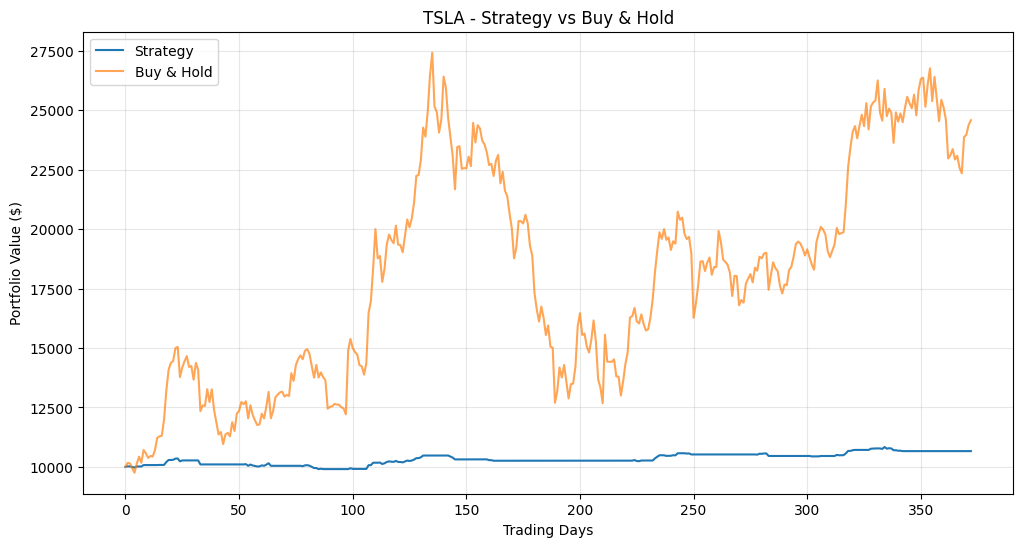

In [69]:
#RSI, MACD

import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def calculate_rsi(data, period=14):
  pricechanges = data['Close'].diff()
  gains = pricechanges.where(pricechanges > 0, 0)
  loss = -pricechanges.where(pricechanges < 0, 0)

  avggain = gains.rolling(window=period).mean()
  avgloss = loss.rolling(window=period).mean()


  rs = avggain / avgloss
  rsi = 100 - (100 / (1 + rs))
  data['RSI'] = rsi
  return data

def macd(data, fast=12, slow=26, signal=9):
  emafast = data['Close'].ewm(span=fast, adjust=False).mean()
  emaslow = data['Close'].ewm(span=slow, adjust=False).mean()
  macd = emafast - emaslow
  sig = macd.ewm(span=signal, adjust=False).mean()
  histo = macd - sig

  data['MACD'] = macd
  data['SIGNAL'] = sig
  data['HISTO'] = histo

  return data


def calcmacd(data, fast=12, slow=26, signal=9):
  data = macd(data)
  data['MACDSIGNAL'] = 0
  data['MACDCROSS'] = 0

  bullish = (data['MACD'] > data['SIGNAL']) & (data['MACD'].shift(1) <= data['SIGNAL'].shift(1))

  # Bearish signal: MACD crosses below Signal line
  bearish = (data['MACD'] < data['SIGNAL']) & (data['MACD'].shift(1) >= data['SIGNAL'].shift(1))

  data.loc[bullish, 'MACDSIGNAL'] = 1
  data.loc[bearish, 'MACDSIGNAL'] = -1

  data.loc[bullish, 'MACDCROSS'] = 1
  data.loc[bearish, 'MACDCROSS'] = -1
  return data


choice = input('Choose your stock to train on: ')
print(f'Downloading stock data of {choice}')
data = yf.download(choice, period='5y')

print('Calculating Indicators.....')
close_prices = data['Close']
if hasattr(close_prices, 'columns'):  # If it's a DataFrame
    close_prices = close_prices.iloc[:, 0]
clean_data = pd.DataFrame()
clean_data['Close'] = close_prices
clean_data['High'] = data['High']
clean_data['Low'] = data['Low']


clean_data = calcmacd(calculate_rsi(clean_data))
clean_data = clean_data.dropna()

clean_data['Future_5d_Up'] = (clean_data['Close'].shift(-5) > clean_data['Close']).astype(int)

clean_data['MA50'] = clean_data['Close'].rolling(50).mean()



# Only trade with the trend
clean_data['MA50_Lag'] = clean_data['MA50'].shift(1)
features = ['RSI', 'MACD', 'SIGNAL']

X = clean_data[features]
y = clean_data['Future_5d_Up']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, shuffle=False)

print('Training...')
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f'\nModel Accuracy: {accuracy:.1%}')

print('\nFeature Importance')
feature_names = features
importances = model.feature_importances_

for name, importance in zip(feature_names, importances):
  print(f'{name}: {importance:.1%}')


cash = 10000
shares = 0
portfolio = []
trades = []
position = 0

def calculate_atr_sl_tp(current_price, data, current_idx, period=14, risk_multiplier=1.5, reward_ratio=2.0):
    data_slice = data.loc[:current_idx]

    high_low = data_slice['High'] - data_slice['Low']
    high_close = np.abs(data_slice['High'] - data_slice['Close'].shift())
    low_close = np.abs(data_slice['Low'] - data_slice['Close'].shift())
    true_range = np.maximum(high_low, np.maximum(high_close, low_close))

    atr_series = true_range.rolling(period).mean()

    # Handle NaN values by using the last available ATR
    if pd.isna(atr_series.iloc[-1]) or atr_series.iloc[-1] == 0:
        atr = current_price * 0.02  # Fallback: 2% of price
    else:
        atr = atr_series.iloc[-1]

    stop_loss = current_price - (atr * risk_multiplier)
    take_profit = current_price + (atr * risk_multiplier * reward_ratio)

    return stop_loss, take_profit

for i in range(len(X_test)):
  currentf = X_test.iloc[i:i+1]
  current_idx = X_test.index[i]  # This is a date like '2023-01-15'
  currentclose = clean_data['Close'].loc[current_idx]
  ma50 = clean_data['MA50_Lag'].loc[current_idx]  # Get the MA50 value
  above_ma50 = currentclose > ma50  # Use .loc with the date index


  probability = model.predict_proba(currentf)[0][1]

  if above_ma50 and probability > 0.55 and shares == 0:
      sl, tp = calculate_atr_sl_tp(currentclose, clean_data, current_idx)
      risk = 0.1 + (probability - 0.55) * (0.04) / 0.35
      sharestobuy = (cash*risk) / currentclose
      cash -= sharestobuy*currentclose
      shares += sharestobuy
      trades.append(f'BOUGHT {sharestobuy} SHARES AT ${currentclose}, USING ${sharestobuy*currentclose}')
      position = 1
  elif shares > 0:
      should_exit = (probability < 0.4 or
                      currentclose <= sl or
                      currentclose >= tp)

      if should_exit:
          cash += shares * currentclose
          profit = shares * (currentclose - (cash / (cash + shares * currentclose)))
          reason = "SL" if currentclose <= sl else "TP" if currentclose >= tp else "Low Prob"
          trades.append(f'SELL {shares:.2f} @ ${currentclose:.2f} | {reason} | Profit: ${profit:.2f}')
          shares = 0
          position = 0

  portfolio.append(cash + shares*currentclose)




initial_cash = 10000
strategy_profit = portfolio[-1] - initial_cash
print(f"\n=== RESULTS ===")
print(f"Starting: ${initial_cash:,.2f}")
print(f"Strategy Final: ${portfolio[-1]:,.2f}")
print(f"Strategy Profit: ${strategy_profit:,.2f}")

# Buy & Hold comparison
test_prices = clean_data['Close'].loc[X_test.index]
buy_hold_value = initial_cash * (test_prices.iloc[-1] / test_prices.iloc[0])
buy_hold_profit = buy_hold_value - initial_cash
print(f"Buy & Hold: ${buy_hold_value:,.2f} (${buy_hold_profit:,.2f})")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(range(len(portfolio)), portfolio, label='Strategy')
plt.plot(range(len(test_prices)),
         [initial_cash * (p / test_prices.iloc[0]) for p in test_prices],
         label='Buy & Hold', alpha=0.7)
plt.title(f'{choice} - Strategy vs Buy & Hold')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Trading Days')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



